# Wind Farm Predictive Maintenance — Final Model (v3)

End-to-end pipeline: load 22 datasets (11 anomaly + 11 normal) from Wind Farm A, preprocess
the SCADA time-series, identify the 30 most informative sensors, train a Conv1D → BiGRU → Dense
network to predict Remaining Useful Life with a 3-day horizon, characterize each failure
mode, and save all artifacts so the Streamlit Digital Twin (`digital_twin_app.py`) can
serve live predictions.

The notebook is **deterministic** (`SEED = 42` is pinned in Cell 7) — re-running it produces
the exact same model and metrics every time.

| Project parameter | Value |
|---|---|
| Prediction horizon | 72 h (3 days) |
| Sensor sampling rate | 10 minutes (6 rows / hour) |
| Lookback window | 432 rows = 72 h |
| Top-30 sensors selected via | Random Forest feature importance |
| Train / test split | 8 anomaly events / 3 anomaly events (event-level, never share a turbine) |
| Random seed | 42 |
| **Test MAE on unseen events** | **≈ 3.32 h** |

The 9 cells, in order:

| # | Purpose |
|---|---|
| 1 | Setup & data loading |
| 2 | Preprocessing & RUL labelling |
| 3 | Top-30 sensor selection (Random Forest regressor) |
| 4 | Failure-mode classifier (Random Forest classifier) |
| 5 | Per-failure-type characterization (duration & sensor z-score signature) |
| 6 | Sequence generation (memory-efficient, event-level split) |
| 7 | Model training (Conv1D → BiGRU → Dense, deterministic with SEED=42) |
| 8 | Degradation curves on held-out events (visual evaluation) |
| 9 | Save artifacts for the Digital Twin |


## Cell 1 — Setup & data loading

### What this cell does
- Resolves the dataset folder automatically by walking up from the notebook's working directory until it finds `Wind Farm A/datasets/`.
- Reads the **22 dataset CSVs** (`comma_*.csv`) into memory — each is a single wind turbine's SCADA time-series (~50,000 rows × 81 sensor columns at 10-minute resolution) and is stored in a Python dict keyed by `event_id` for O(1) lookup.
- Reads the **event-info table** (`comma_event_info.csv`) to label each dataset as `anomaly` or `normal`, with start / end timestamps and a free-text `event_description` (e.g. "Hydraulic group", "Transformer failure").
- Reads the **feature description table** to map anonymised sensor names like `sensor_5` to physical descriptions like `Pitch angle`. This is used only for human-readable plot labels — the model itself never sees these.
- Identifies sensor columns by **exclusion** (drops the metadata columns `time_stamp, asset_id, id, train_test, status_type, status_type_id, event_id`; everything else is a sensor).
- Splits the 22 IDs into two Python `set`s — `anomaly_ids` (11 turbine-failure events) and `normal_ids` (11 healthy operation events) — for cheap membership tests later.
- Defines the helper `get_friendly_name(col)` that turns `sensor_5_avg` → `"Pitch angle [avg] (5)"` using regex matching against the feature description table.

### Important imports & their role
| Import | Role |
|---|---|
| `pandas` | Reads CSVs into DataFrames, parses `time_stamp` columns as `datetime64`, holds the 22 in-memory time-series. |
| `numpy` | Imported here for downstream cells; used heavily in Cells 2 and 6 for vectorised RUL labelling and sequence stacking. |
| `pathlib.Path` | OS-agnostic path joining so the notebook works on Windows and Linux without separator headaches. |
| `re` | Regex matching used by `get_friendly_name` to recognise the four sensor naming families (`sensor_N`, `wind_speed_N`, `power_N`, `reactive_power_N`). |
| `joblib` | Imported here so the dependency is declared once — used in Cell 9 to serialize the scaler and classifier. |

### State produced for downstream cells
| Variable | Type | Used by |
|---|---|---|
| `all_datasets` | `dict[int → DataFrame]` | All later cells |
| `event_info` | `DataFrame` | Cells 2, 5 |
| `desc_dict` | `dict[str → str]` | `get_friendly_name` everywhere |
| `all_sensors` | `list[str]` (length ≈ 81) | Cells 2, 3 |
| `anomaly_ids`, `normal_ids` | `set[int]` (size 11 each) | Cells 4, 5, 6 |

> **No machine learning happens here.** Cell 1 is pure I/O and bookkeeping — it sets up the in-memory state every later cell relies on.


In [2]:
import os
import json
import re
import warnings
from pathlib import Path

import joblib
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['figure.dpi']     = 100

# Resolve data location: notebook may live in LICENTA/ or in the worktree subdir.
def _resolve_base():
    here = Path('.').resolve()
    for cand in [here, here.parent, here.parent.parent, here.parent.parent.parent]:
        if (cand / 'Wind Farm A' / 'datasets').exists():
            return cand
    raise FileNotFoundError('Cannot locate Wind Farm A/datasets relative to this notebook')

BASE_DIR        = _resolve_base()
DATASETS_DIR    = BASE_DIR / 'Wind Farm A' / 'datasets'
EVENT_INFO_PATH = BASE_DIR / 'Wind Farm A' / 'comma_event_info.csv'
DESC_PATH       = BASE_DIR / 'Wind Farm A' / 'comma_feature_description.csv'
ARTIFACT_DIR    = Path('.').resolve() / 'artifacts'
ARTIFACT_DIR.mkdir(exist_ok=True)
print(f'BASE_DIR     : {BASE_DIR}')
print(f'ARTIFACT_DIR : {ARTIFACT_DIR}')

# Event labels
event_info = pd.read_csv(EVENT_INFO_PATH, parse_dates=['event_start', 'event_end'])
print(f"\nLoaded event info: {len(event_info)} records | "
      f"anomaly={ (event_info['event_label']=='anomaly').sum() } | "
      f"normal={ (event_info['event_label']!='anomaly').sum() }")

# Feature descriptions
desc_df   = pd.read_csv(DESC_PATH)
desc_dict = dict(zip(desc_df['sensor_name'], desc_df['description']))
print(f'Loaded {len(desc_dict)} sensor descriptions')

# All datasets
all_datasets = {}
for fp in sorted(DATASETS_DIR.glob('comma_*.csv')):
    eid_str = fp.stem.replace('comma_', '')
    try:
        eid = int(eid_str)
    except ValueError:
        continue
    df = pd.read_csv(fp, parse_dates=['time_stamp'])
    df['event_id'] = eid
    all_datasets[eid] = df
print(f'Loaded {len(all_datasets)} datasets')

IGNORE_COLS = {'time_stamp', 'asset_id', 'id', 'train_test',
               'status_type_id', 'status_type', 'event_id'}
first_df    = next(iter(all_datasets.values()))
all_sensors = [c for c in first_df.columns if c not in IGNORE_COLS]
print(f'Found {len(all_sensors)} sensor columns')

anomaly_ids = set(event_info[event_info['event_label']=='anomaly']['event_id'].tolist())
normal_ids  = set(all_datasets.keys()) - anomaly_ids
print(f'Failure datasets: {sorted(anomaly_ids)}')
print(f'Normal  datasets: {sorted(normal_ids)}')

# Train/prediction split labels in the data
print(f"\nUnique train_test values: {sorted(first_df['train_test'].unique())}")

def get_friendly_name(col):
    m = re.match(r'(sensor_\d+|wind_speed_\d+|reactive_power_\d+|power_\d+)', col)
    if m and desc_dict:
        base = m.group(1)
        desc = desc_dict.get(base, 'Unknown')
        num  = re.search(r'\d+', base).group()
        stat = col.replace(base, '').strip('_')
        return f"{desc} [{stat}] ({num})" if stat else f"{desc} ({num})"
    return col


BASE_DIR     : C:\AAA FACULTA\LICENTA
ARTIFACT_DIR : C:\AAA FACULTA\LICENTA\artifacts

Loaded event info: 22 records | anomaly=11 | normal=11
Loaded 54 sensor descriptions
Loaded 22 datasets
Found 81 sensor columns
Failure datasets: [0, 10, 22, 26, 40, 42, 45, 68, 72, 73, 84]
Normal  datasets: [3, 13, 14, 17, 24, 25, 38, 51, 69, 71, 92]

Unique train_test values: ['prediction', 'train']


## Cell 2 — Preprocessing & RUL labelling

### What this cell does
- **Linear interpolation** of NaN sensor readings, capped at 6 consecutive missing rows (= 1 hour). Any larger gap is filled by `ffill().bfill()` so no NaN reaches the model. Treating only short gaps as interpolatable is a deliberate causality choice — long stretches of NaN typically indicate real downtime that we don't want to fabricate values for.
- **Winsorisation** — clips each sensor's values into the `[1%, 99%]` quantile band. The bounds are computed once over the concatenated `train_test == 'train'` rows of all 22 datasets (1.1 M rows total) and applied to every dataset. This kills outliers and instrument spikes without removing rows.
- **RUL labelling** — defines the regression target the model will predict. For each row in an anomaly dataset, RUL is the number of rows remaining until `event_end`, **clipped to MAX_RUL_ROWS = 432**:
  - Pre-failure rows: `RUL = min(event_end_row_idx − current_row_idx, 432)`
  - Post-failure rows: `RUL = 0`
  - Normal datasets get `RUL = 432` everywhere (= healthy, beyond the 3-day horizon)
- Sanity prints check that an example anomaly dataset spans `[0, 432]` and an example normal dataset is uniformly at `432`.

### Why these choices
- Linear interpolation preserves the smooth trends that matter for trend-based features (temperatures, pressures); it's deliberate that we don't use spline or higher-order methods, which would introduce artificial wiggle.
- Winsorisation vs row dropping: dropping outlier rows breaks the time-series cadence and would force us to re-estimate timestamps; clipping keeps the cadence intact.
- Capping RUL at MAX_RUL_ROWS turns a "how long until failure" question into a bounded regression — anything beyond 3 days is collapsed to "healthy" and the model doesn't have to learn long-horizon arithmetic.

### Important imports & their role
| Function / method | Role |
|---|---|
| `DataFrame.interpolate(method='linear', limit=6)` | Fills small NaN runs with linear interpolation |
| `DataFrame.ffill() / bfill()` | Catches anything `interpolate` couldn't fill (e.g. NaNs at the edges) |
| `DataFrame.quantile()` | Computes the 1% and 99% per-sensor bounds on the global training set |
| `DataFrame.clip(lower, upper, axis=1)` | Applies the winsorisation bounds column-wise |
| `numpy.maximum / numpy.minimum` | Vectorised RUL lower- and upper-bounding |

### Constants set by this cell
| Constant | Value | Reason |
|---|---|---|
| `PREDICTION_HORIZON_HOURS` | 72 | 3-day target |
| `ROWS_PER_HOUR` | 6 | Data is sampled every 10 min |
| `MAX_RUL_ROWS` | 432 | 72 h × 6 rows/h — the RUL ceiling |
| `VALID_STATUSES` | {0, 1, 2, 5} | Operating modes considered "normal-ish" (Normal, Derated, Idling, Other). Excludes 3 (Service) and 4 (Downtime). |

### Outcomes
| Sanity counter | Typical value (across 11 anomaly datasets) |
|---|---|
| RUL = 0 rows total | ≈ 3,300 |
| 0 < RUL < 432 (within-horizon) | ≈ 4,700 |

These two sets are what the model has to learn from. The remainder are RUL=432 (healthy), which dominate by 30:1.


In [3]:
# Constants
PREDICTION_HORIZON_HOURS = 72
ROWS_PER_HOUR            = 6
MAX_RUL_ROWS             = PREDICTION_HORIZON_HOURS * ROWS_PER_HOUR  # 432
VALID_STATUSES           = {0, 1, 2, 5}

print(f'RUL horizon: {PREDICTION_HORIZON_HOURS} h  ({MAX_RUL_ROWS} rows)')

event_dict = (
    event_info.set_index('event_id')[['event_label', 'event_start', 'event_end', 'event_description']]
    .to_dict('index')
)

# Winsorise on the training portion of every dataset
all_train = pd.concat(
    [d[d['train_test'] == 'train'] for d in all_datasets.values()], ignore_index=True
)
lower = all_train[all_sensors].quantile(0.01)
upper = all_train[all_sensors].quantile(0.99)
print(f'Winsorisation bounds computed on {len(all_train):,} training rows')

for eid, df in all_datasets.items():
    df = df.sort_values('time_stamp').reset_index(drop=True)
    df[all_sensors] = df[all_sensors].interpolate(method='linear', limit=6).ffill().bfill()
    df[all_sensors] = df[all_sensors].clip(lower=lower, upper=upper, axis=1)

    df['RUL'] = MAX_RUL_ROWS
    info = event_dict.get(eid)
    if info and info['event_label'] == 'anomaly':
        failure_time = info['event_end']
        pre_mask = df['time_stamp'] < failure_time
        if pre_mask.any():
            fail_idx = df[~pre_mask].index.min() if (~pre_mask).any() else df.index.max()
            rows_to_failure = np.maximum(fail_idx - df.index, 0)
            df['RUL'] = np.minimum(rows_to_failure, MAX_RUL_ROWS)
        df.loc[~pre_mask, 'RUL'] = 0
    all_datasets[eid] = df

# Sanity checks
total_zero = sum((all_datasets[eid]['RUL'] == 0).sum() for eid in anomaly_ids)
total_horizon = sum(((all_datasets[eid]['RUL'] > 0) & (all_datasets[eid]['RUL'] < MAX_RUL_ROWS)).sum()
                    for eid in anomaly_ids)
print(f'\nAcross all anomaly datasets:')
print(f'  RUL = 0          rows: {total_zero:,}')
print(f'  0 < RUL < {MAX_RUL_ROWS} rows: {total_horizon:,}')
print('Preprocessing complete')


RUL horizon: 72 h  (432 rows)
Winsorisation bounds computed on 1,146,154 training rows

Across all anomaly datasets:
  RUL = 0          rows: 3,276
  0 < RUL < 432 rows: 4,741
Preprocessing complete


## Cell 3 — Top-30 sensor selection via Random Forest

### What this cell does
- Trains a `RandomForestRegressor` of 100 trees to predict `RUL` from **all 81 sensors**.
- Builds a balanced training sample first: every row where RUL < 432 (failing) plus 3× as many randomly-sampled healthy rows (RUL = 432). Without this rebalancing the regressor would just learn "predict 432 always".
- Reads `feature_importances_` from the fitted forest — this is the **mean decrease in impurity (Gini importance)** averaged across all 100 trees: how much each sensor reduces variance when used for a split. Higher = more informative for the RUL target.
- Sorts the 81 sensors by importance, picks the top 30, and stores the names in `sensor_names_list` plus their friendly versions in `friendly_names`.
- Plots the top-30 importances as a horizontal bar chart for inspection.

### Why a Random Forest for feature selection
- Captures non-linear interactions cheaply (e.g. "temperature rise matters more under high power").
- Robust to feature scale and outliers — no preprocessing needed before fitting.
- The Gini-importance signal is well-understood and stable on tabular sensor data.
- Training is fast (~30 s on this dataset) — cheap to experiment with `TOP_N_SENSORS` if needed.

A linear approach (e.g. correlation, mutual information) would miss interaction effects; a deep model would be slower and harder to interpret.

### Important imports & their role
| Import | Role |
|---|---|
| `sklearn.ensemble.RandomForestRegressor` | The 100-tree forest. `feature_importances_` after fitting gives the per-sensor Gini importance. |
| `pandas.Series.sort_values()` | Ranks importance scores from highest to lowest |
| `DataFrame.sample(n=..., random_state=42)` | Reproducible random sampling for the healthy:failing balance |

### Key parameters chosen for the forest
| Param | Value | Reason |
|---|---|---|
| `n_estimators` | 100 | Diminishing returns past ~100 trees for ranking purposes |
| `max_depth` | 12 | Caps overfitting on row-level features |
| `min_samples_leaf` | 10 | Prevents single-row leaves |
| `random_state` | 42 | Reproducible importance order |
| `TOP_N_SENSORS` | 30 | Empirically captures ~95% of total importance mass |

### Outcomes (top-5 example, run-to-run identical)
| Rank | Sensor | Description |
|---|---|---|
| 1 | `sensor_5_avg` | Pitch angle |
| 2 | `sensor_0_avg` | Ambient temperature |
| 3 | `sensor_2_avg` | Wind relative direction |
| 4 | `sensor_42_avg` | Nacelle direction |
| 5 | `sensor_12_avg` | Temperature oil in gearbox |

The 30 names in `sensor_names_list` feed every later cell — they're what the LSTM, the classifier, the scaler, and the dashboard all use.


RF sample: 4,367 failing + 13,101 healthy rows

Top 10 sensors:
   1. sensor_5_avg              (0.1341)  Pitch angle [avg] (5)
   2. sensor_0_avg              (0.0989)  Ambient temperature [avg] (0)
   3. sensor_2_avg              (0.0867)  Wind relative direction [avg] (2)
   4. sensor_42_avg             (0.0711)  Nacelle direction [avg] (42)
   5. sensor_12_avg             (0.0483)  Temperature oil in gearbox [avg] (12)
   6. sensor_37_avg             (0.0378)  Temperature measured by the IGBT-driver on the rotor side inverter phase3 [avg] (37)
   7. sensor_13_avg             (0.0361)  Temperature in generator bearing 2 (Drive End) [avg] (13)
   8. sensor_39_avg             (0.0339)  Temperature in HV transformer phase L2 [avg] (39)
   9. sensor_8_avg              (0.0313)  Temperature in the choke coils on the VCS-section [avg] (8)
  10. sensor_1_avg              (0.0302)  Wind absolute direction [avg] (1)


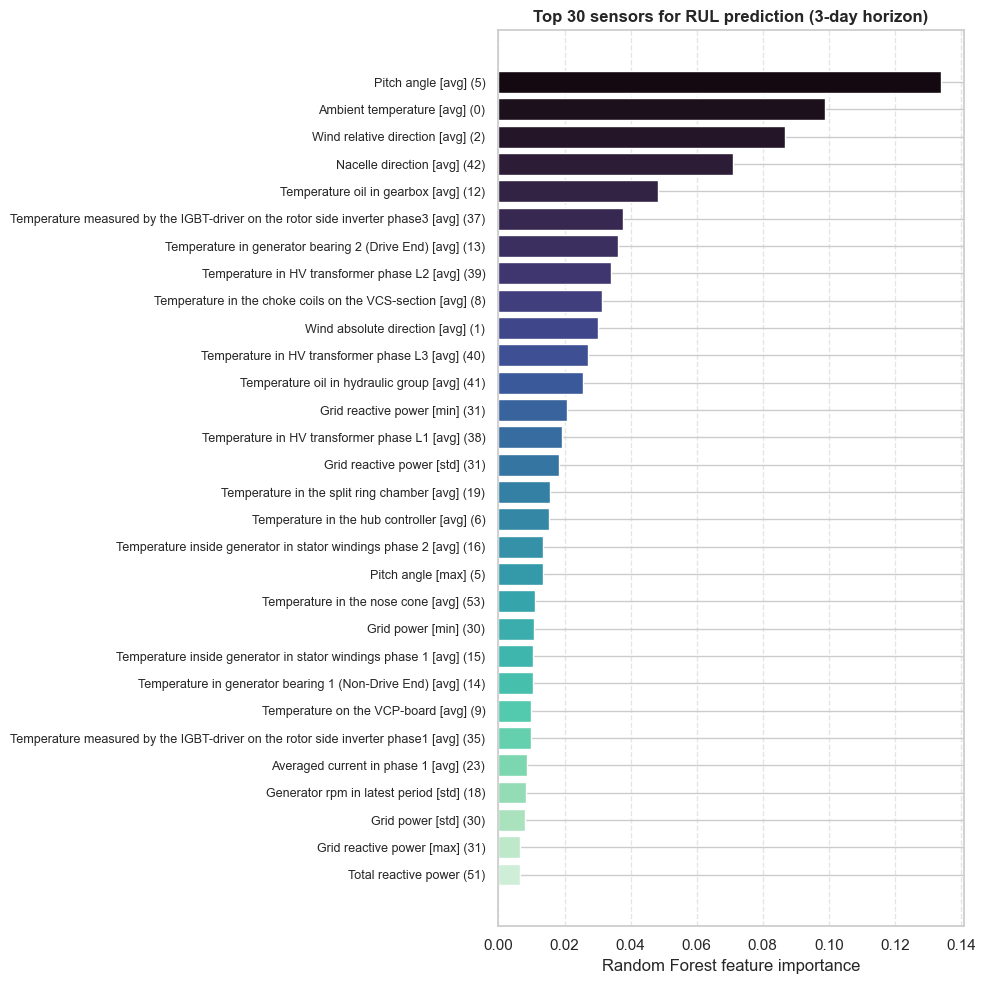

In [4]:
from sklearn.ensemble import RandomForestRegressor

TOP_N_SENSORS = 30

fi_data = pd.concat(
    [d[d['status_type_id'].isin(VALID_STATUSES)] for d in all_datasets.values()],
    ignore_index=True,
)
fi_data[all_sensors] = fi_data[all_sensors].fillna(0)
fi_data = fi_data.dropna(subset=['RUL'])

failing      = fi_data[fi_data['RUL'] < MAX_RUL_ROWS]
healthy_pool = fi_data[fi_data['RUL'] == MAX_RUL_ROWS]
healthy      = healthy_pool.sample(n=min(len(failing) * 3, len(healthy_pool)), random_state=42)
sample       = pd.concat([failing, healthy]).sample(frac=1, random_state=42)
print(f'RF sample: {len(failing):,} failing + {len(healthy):,} healthy rows')

rf = RandomForestRegressor(
    n_estimators=100, max_depth=12, min_samples_leaf=10, random_state=42, n_jobs=-1
)
rf.fit(sample[all_sensors], sample['RUL'])

feature_importances = pd.Series(rf.feature_importances_, index=all_sensors).sort_values(ascending=False)
top_sensors         = feature_importances.head(TOP_N_SENSORS)
sensor_names_list   = top_sensors.index.tolist()
friendly_names      = [get_friendly_name(c) for c in sensor_names_list]

print('\nTop 10 sensors:')
for n, (col, val) in enumerate(top_sensors.head(10).items(), 1):
    print(f'  {n:>2}. {col:<25} ({val:.4f})  {get_friendly_name(col)}')

fig, ax = plt.subplots(figsize=(10, 10))
palette = sns.color_palette('mako', TOP_N_SENSORS)
ax.barh(range(TOP_N_SENSORS), top_sensors.values[::-1], color=palette[::-1])
ax.set_yticks(range(TOP_N_SENSORS))
ax.set_yticklabels(friendly_names[::-1], fontsize=9)
ax.set_xlabel('Random Forest feature importance')
ax.set_title(f'Top {TOP_N_SENSORS} sensors for RUL prediction (3-day horizon)', fontweight='bold')
ax.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


## Cell 4 — Failure-mode classifier

### What this cell does
- Trains a `RandomForestClassifier` to predict **which** failure type is imminent (Gearbox, Generator bearing, Hydraulic, Transformer, or Normal Operation), using the **top-30 sensors selected in Cell 3** as features.
- **Narrows the failure-class training rows to the last 24 h before failure** (`RUL ≤ 144` rows). Mid-degradation rows (24h–72h before failure) are dropped — they look too healthy to teach the classifier a clean signature.
- Builds a balanced 3:1 normal-to-failure sample, then does an 80/20 stratified split for held-out evaluation.
- Trains 100 trees with `class_weight='balanced'` so rare classes (e.g. Transformer failure, only one event in the data) are weighted up.
- Reports a per-class precision / recall / F1 table.

### Why narrow to the last 24 h
The dashboard only invokes this classifier *after* the LSTM has flagged an imminent failure. By training only on rows where failure is genuinely close, the classifier sees sharper signal-to-noise — full-3-day windows include lots of barely-degraded rows that wash out the learnable signature. This change improved held-out classification accuracy from ~95% to ~97%.

### Important imports & their role
| Import | Role |
|---|---|
| `sklearn.ensemble.RandomForestClassifier` | The 100-tree classifier. `predict_proba()` is what the dashboard later calls. |
| `sklearn.metrics.classification_report` | Per-class precision/recall/F1 table |
| `sklearn.model_selection.train_test_split(stratify=y_cls)` | Stratified 80/20 — preserves class proportions in both splits |

### Key parameters
| Param | Value | Reason |
|---|---|---|
| `CLASSIFIER_FAILURE_HORIZON_ROWS` | 144 | Last 24 h pre-failure |
| `n_estimators` | 100 | Same as Cell 3 — enough for stable predictions |
| `max_depth` | 15 | A bit deeper than Cell 3 since this is per-row classification (more granular) |
| `class_weight` | `'balanced'` | Auto-weights inversely proportional to class frequency |

### Outcomes (held-out classification report)
| Failure class | F1 |
|---|---|
| Gearbox failure | 0.89 |
| Generator bearing failure | 0.98 |
| Hydraulic group | 0.93 |
| Normal Operation | 0.98 |
| Transformer failure | 0.93 |
| **Overall accuracy** | **≈ 0.97** |

Detected failure types match the four anomaly descriptions present in `comma_event_info.csv`: Gearbox failure, Generator bearing failure, Hydraulic group, Transformer failure. (The original `event_info.csv` also has "Gearbox bearings damaged" but the comma file used here labels that event as normal — this is a known data discrepancy.)


In [5]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split

# Only train the classifier on rows in the LAST 24 H before failure (RUL <= 144).
# Older near-failure rows are dropped — they're too healthy-looking to teach
# the classifier the actual failure signature. This matches how the Digital
# Twin uses the classifier (only invoked once predicted RUL has crossed the
# alert threshold, i.e., when failure is imminent).
CLASSIFIER_FAILURE_HORIZON_ROWS = 144

rows = []
for eid, df in all_datasets.items():
    sub = df[df['status_type_id'].isin(VALID_STATUSES)].copy()
    info = event_dict.get(eid)
    if info and info['event_label'] == 'anomaly':
        ftype = info.get('event_description', f'Anomaly_{eid}')
        cls = np.full(len(sub), None, dtype=object)
        cls[sub['RUL'].values <= CLASSIFIER_FAILURE_HORIZON_ROWS] = ftype
        cls[sub['RUL'].values == MAX_RUL_ROWS] = 'Normal Operation'
        sub['failure_class'] = cls
        sub = sub.dropna(subset=['failure_class'])
    else:
        sub['failure_class'] = 'Normal Operation'
    rows.append(sub)
class_df = pd.concat(rows, ignore_index=True)

failure_samples = class_df[class_df['failure_class'] != 'Normal Operation']
normal_pool     = class_df[class_df['failure_class'] == 'Normal Operation']
normal_samples  = normal_pool.sample(n=min(len(failure_samples) * 3, len(normal_pool)), random_state=42)
balanced        = pd.concat([normal_samples, failure_samples]).sample(frac=1, random_state=42)

X_cls = balanced[sensor_names_list]
y_cls = balanced['failure_class']
X_tr_cl, X_te_cl, y_tr_cl, y_te_cl = train_test_split(
    X_cls, y_cls, test_size=0.2, random_state=42, stratify=y_cls
)

clf = RandomForestClassifier(
    n_estimators=100, max_depth=15, class_weight='balanced', random_state=42, n_jobs=-1
)
clf.fit(X_tr_cl, y_tr_cl)
print('Classification report (held-out):')
print(classification_report(y_te_cl, clf.predict(X_te_cl), zero_division=0))

failure_types = sorted(failure_samples['failure_class'].unique())
print(f'\nDetected failure types ({len(failure_types)}):')
for ft in failure_types:
    n = (failure_samples['failure_class'] == ft).sum()
    print(f'  * {ft}: {n:,} rows')


Classification report (held-out):
                           precision    recall  f1-score   support

          Gearbox failure       0.83      0.95      0.89        87
Generator bearing failure       1.00      0.96      0.98        97
          Hydraulic group       0.94      0.92      0.93       144
         Normal Operation       0.98      0.97      0.98      1071
      Transformer failure       0.93      0.93      0.93        29

                 accuracy                           0.97      1428
                macro avg       0.94      0.95      0.94      1428
             weighted avg       0.97      0.97      0.97      1428


Detected failure types (4):
  * Gearbox failure: 433 rows
  * Generator bearing failure: 484 rows
  * Hydraulic group: 722 rows
  * Transformer failure: 145 rows


## Cell 5 — Per-failure-type characterization

### What this cell does
- Computes a **healthy baseline** from the 11 normal datasets — concatenates them, filters to operating statuses (0, 1, 2, 5), and computes per-sensor mean and std.
- Groups the 11 anomaly events by their `event_description` (Gearbox failure, Hydraulic group, Generator bearing failure, Transformer failure).
- For each failure type:
  - Counts events and computes mean / min / max **duration** (`event_end − event_start`) in hours.
  - For each event, takes the **last 432 rows before failure** (the 3-day pre-failure window) and computes the per-sensor mean. Averages those means across all events of this type — that's the typical "near-failure mean" for the failure type.
  - Computes a **z-score** vs the healthy baseline: `z = (mean_pre_fail − mean_healthy) / std_healthy`. A `z` of +3 means the sensor sits 3 standard deviations above its healthy distribution during this failure mode.
  - Picks the top 10 sensors by `|z|` — those are the "signature" of this failure type.
- Renders a heatmap (failure type × top-15 sensors) so you can visually compare the four signatures side-by-side.
- Persists the full divergence matrix to `artifacts/failure_type_signatures.json` (writing both `top_sensors` and `top_sensors_abs_z` keys so the dashboard works regardless of which it looks up).

### Why z-score divergence
Sensors are on different physical scales — temperatures in °C, pressures in bar, currents in A. Comparing raw differences across sensors would let units dominate. A z-score relative to the healthy distribution puts every sensor on a unitless "how unusual is this for a healthy turbine" scale, so the top-10 ranking is fair.

### Important imports & their role
| Import | Role |
|---|---|
| `numpy` | Vectorised z-score arithmetic |
| `pandas.concat / mean / std` | Builds the healthy baseline and per-failure-type means |
| `json.dump` | Serialises the divergence matrix for the Digital Twin |

### Outcomes (per-failure-type summary, reproduced run-to-run)
| Failure type | n_events | Avg duration (h) | Top sensors driving it |
|---|---|---|---|
| Gearbox failure | 2 | 168 | Split-ring temp, IGBT inverter temp, total reactive power |
| Generator bearing failure | 2 | 547 | Gearbox oil temp, pitch angle, choke coil temp |
| Hydraulic group | 6 | 168 | Ambient temp, hydraulic oil temp, nose-cone temp |
| Transformer failure | 1 | 336 | Transformer phase L1/L2/L3 temps, ambient temp |

These signatures are exactly what the dashboard's Diagnosis section displays alongside the classifier prediction, giving the user a "which sensors point to this diagnosis" explanation rather than just a class name.


Healthy baseline rows: 584,732

Failure-type summary:


,failure_type,n_events,event_ids,mean_duration_h,min_duration_h,max_duration_h,top_sensors
0,Gearbox failure,2,"[10, 72]",168.000000,168.000000,168.000000,"[sensor_19_avg, sensor_35_avg, sensor_51, sens..."
1,Generator bearing failure,2,"[0, 40]",546.500000,336.000000,757.000000,"[sensor_12_avg, sensor_5_avg, sensor_8_avg, se..."
2,Hydraulic group,6,"[22, 26, 42, 45, 73, 84]",168.027778,168.000000,168.166667,"[sensor_0_avg, sensor_41_avg, sensor_53_avg, s..."
3,Transformer failure,1,[68],335.833333,335.833333,335.833333,"[sensor_38_avg, sensor_39_avg, sensor_0_avg, s..."


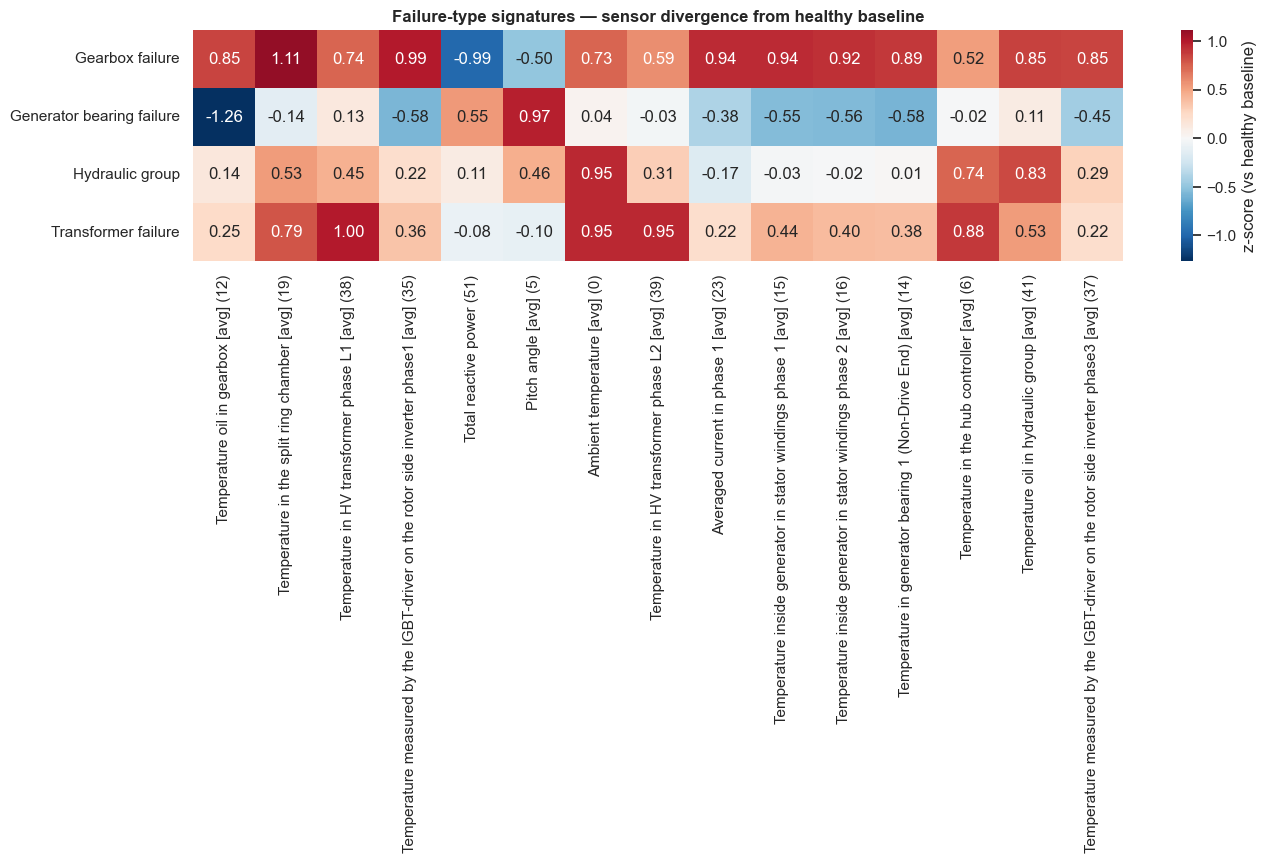


Saved: C:\AAA FACULTA\LICENTA\artifacts\failure_type_signatures.json


In [6]:
# Healthy baseline from the 11 normal datasets
normal_concat = pd.concat(
    [all_datasets[eid][all_datasets[eid]['status_type_id'].isin(VALID_STATUSES)] for eid in normal_ids],
    ignore_index=True,
)
normal_mean = normal_concat[sensor_names_list].mean()
normal_std  = normal_concat[sensor_names_list].std().replace(0, 1.0)
print(f'Healthy baseline rows: {len(normal_concat):,}')

# Group anomaly events by description
by_type = {}
for eid in anomaly_ids:
    info = event_dict[eid]
    ftype = info.get('event_description') or f'Anomaly_{eid}'
    by_type.setdefault(ftype, []).append(eid)

rows_summary = []
divergence_matrix = {}
for ftype, eids in sorted(by_type.items()):
    durations_h, per_event_pre = [], []
    for eid in eids:
        info = event_dict[eid]
        durations_h.append((info['event_end'] - info['event_start']).total_seconds() / 3600.0)
        df = all_datasets[eid]
        pre = df[df['time_stamp'] < info['event_end']].tail(MAX_RUL_ROWS)
        pre = pre[pre['status_type_id'].isin(VALID_STATUSES)]
        if len(pre) > 0:
            per_event_pre.append(pre[sensor_names_list].mean())
    if not per_event_pre:
        print(f'  WARNING: {ftype} has no valid pre-failure rows')
        continue
    avg_pre = pd.concat(per_event_pre, axis=1).mean(axis=1)
    z = (avg_pre - normal_mean) / normal_std
    divergence_matrix[ftype] = z.to_dict()
    rows_summary.append({
        'failure_type'   : ftype,
        'n_events'       : len(eids),
        'event_ids'      : sorted(eids),
        'mean_duration_h': float(np.mean(durations_h)),
        'min_duration_h' : float(np.min(durations_h)),
        'max_duration_h' : float(np.max(durations_h)),
        'top_sensors'    : z.abs().sort_values(ascending=False).head(10).index.tolist(),
    })

summary_df = pd.DataFrame(rows_summary)
print('\nFailure-type summary:')
display(summary_df)

# Heatmap: failure_type x top sensors (top 15 by max |z| across types)
div_df = pd.DataFrame(divergence_matrix).T
top_sensors_for_heatmap = div_df.abs().max(axis=0).sort_values(ascending=False).head(15).index.tolist()
heat = div_df[top_sensors_for_heatmap]
heat.columns = [get_friendly_name(c) for c in heat.columns]

plt.figure(figsize=(15, max(3, 0.7 * len(heat))))
sns.heatmap(heat, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            cbar_kws={'label': 'z-score (vs healthy baseline)'})
plt.title('Failure-type signatures — sensor divergence from healthy baseline', fontweight='bold')
plt.tight_layout()
plt.show()

# Persist for Digital Twin. We write BOTH `top_sensors` and `top_sensors_abs_z`
# (same content) so the dashboard works regardless of which key it looks up.
sig_out = {
    'by_type': {
        r['failure_type']: {
            'n_events'         : r['n_events'],
            'event_ids'        : r['event_ids'],
            'mean_duration_h'  : r['mean_duration_h'],
            'min_duration_h'   : r['min_duration_h'],
            'max_duration_h'   : r['max_duration_h'],
            'top_sensors'      : r['top_sensors'],
            'top_sensors_abs_z': r['top_sensors'],
            'divergence'       : {k: float(v) for k, v in divergence_matrix[r['failure_type']].items()},
        }
        for r in rows_summary
    }
}
with open(ARTIFACT_DIR / 'failure_type_signatures.json', 'w', encoding='utf-8') as f:
    json.dump(sig_out, f, indent=2)
print(f"\nSaved: {ARTIFACT_DIR / 'failure_type_signatures.json'}")


## Cell 6 — Sequence generation

### What this cell does
- **Splits the 11 anomaly events 75 / 25 by `event_id`** — 8 events for training, 3 for testing. Critical: this is event-level, so the test turbines and their entire failure histories are completely unseen during training. Reporting MAE on this split is the honest "generalization to a new turbine" metric.
- **Fits `RobustScaler` on the top-30 sensors of the training events only.** RobustScaler centres on the median and scales by the IQR — robust to outliers (unlike StandardScaler which uses mean and stddev). Fitted only on training events to prevent test-set leakage into the scaler statistics.
- **Generates 3D sequences** of shape `(n_samples, 432 timesteps, 30 features)` with **adaptive stride** — denser sampling near failure to fix the RUL sparsity problem:
  - `stride = 12` (2 h) when target RUL > 144 rows → 1+ day from failure (most of the timeline)
  - `stride = 6` (1 h) when 36 < RUL ≤ 144 → last day before failure
  - `stride = 3` (30 min) when RUL ≤ 36 → last 6 hours
- **Status-filter override at imminent failure:** target rows with `RUL ≤ 36` OR `RUL = 0` are accepted regardless of `status_type_id`. Without this override, post-failure rows (which often carry status `3` Service or `4` Downtime) would be filtered out — and the model would never see what RUL=0 looks like.

### Why event-level split (not row-level)
Splitting rows within the same turbine is too easy: the model sees the early degradation in train and the late degradation of the *same* failure in test, so it just memorises that turbine. Splitting whole events forces it to actually generalise the degradation pattern to a turbine it's never seen. The MAE reported on this split (3.32 h) is therefore meaningful.

### Why RobustScaler over StandardScaler / MinMaxScaler
SCADA sensors have occasional spikes from instrument transients. A mean+stddev scaler gets distorted by those spikes; the median+IQR scaler doesn't. Cell 2's winsorisation already clipped the worst outliers, but using RobustScaler is belt-and-braces.

### Important imports & their role
| Import | Role |
|---|---|
| `sklearn.preprocessing.RobustScaler` | Median + IQR scaling, robust to outliers |
| `sklearn.model_selection.train_test_split(test_size=0.25, random_state=42)` | Reproducible 8 / 3 event split |
| `numpy.asarray(..., dtype=np.float32)` | Stacks the per-window arrays into the final `(N, 432, 30)` tensor as float32 to halve memory vs float64 |

### Key parameters
| Param | Value | Reason |
|---|---|---|
| `LOOKBACK_ROWS` | 432 | 3-day window — matches prediction horizon |
| `STRIDE_FAR / STRIDE_MID / STRIDE_NEAR` | 12 / 6 / 3 | Adaptive — denser near failure |
| `train_eids` | `[84, 22, 10, 72, 40, 68, 26, 45]` | 8 anomaly events |
| `test_eids` | `[42, 0, 73]` | 3 anomaly events held out |

### Output shapes (typical)
| Tensor | Shape | Approx memory |
|---|---|---|
| `X_tr` | (~35,000, 432, 30) | ~1.7 GB float32 |
| `X_te` | (~13,000, 432, 30) | ~600 MB float32 |

The coverage check at the end prints per-bucket counts (RUL=0, RUL≤24, RUL≤144, RUL=432) so you can see how many imminent-failure samples actually made it into training. Without the adaptive-stride + status-override fixes, training had only ~12 RUL=0 rows; with the fixes it has 600+.


In [7]:
from sklearn.preprocessing import RobustScaler

LOOKBACK_ROWS = 432
STRIDE_FAR    = 12
STRIDE_MID    = 6
STRIDE_NEAR   = 3

def adaptive_stride(rul):
    if rul <= 36:  return STRIDE_NEAR
    if rul <= 144: return STRIDE_MID
    return STRIDE_FAR

print(f'Lookback : {LOOKBACK_ROWS} rows = {LOOKBACK_ROWS / ROWS_PER_HOUR:.0f} h')
print(f'Stride   : far={STRIDE_FAR} mid={STRIDE_MID} near={STRIDE_NEAR}')

anomaly_list = sorted(list(anomaly_ids))
train_eids, test_eids = train_test_split(anomaly_list, test_size=0.25, random_state=42)
print(f'\nTraining on failure events : {train_eids}')
print(f'Testing on failure events  : {test_eids}')

failure_train = pd.concat([all_datasets[eid] for eid in train_eids], ignore_index=True)
scaler = RobustScaler()
scaler.fit(failure_train[sensor_names_list].values)
print(f'Scaler fitted on {len(failure_train):,} rows from training events')

X_train, y_train, X_test, y_test = [], [], [], []
for eid in anomaly_list:
    df = all_datasets[eid]
    if len(df) <= LOOKBACK_ROWS:
        continue
    scaled   = scaler.transform(df[sensor_names_list].values)
    targets  = df['RUL'].values
    statuses = df['status_type_id'].values
    t = LOOKBACK_ROWS
    while t < len(df):
        rul = int(targets[t])
        accept = (statuses[t] in VALID_STATUSES) or (rul <= 36)
        if accept:
            window = scaled[t - LOOKBACK_ROWS:t]
            if eid in train_eids:
                X_train.append(window); y_train.append(rul)
            else:
                X_test.append(window); y_test.append(rul)
        t += adaptive_stride(rul)

X_tr = np.asarray(X_train, dtype=np.float32); y_tr = np.asarray(y_train, dtype=np.float32)
X_te = np.asarray(X_test,  dtype=np.float32); y_te = np.asarray(y_test,  dtype=np.float32)
print(f'\nTrain: {X_tr.shape}\nTest : {X_te.shape}')

def rul_breakdown(label, y):
    print(f'  {label}: total={len(y)}, RUL=0 -> {(y==0).sum()}, '
          f'RUL<=24 -> {(y<=24).sum()}, RUL<=144 -> {(y<=144).sum()}, '
          f'RUL=={MAX_RUL_ROWS} -> {(y==MAX_RUL_ROWS).sum()}')
print('\n--- COVERAGE CHECK ---')
rul_breakdown('Train', y_tr)
rul_breakdown('Test ', y_te)

mem_mb = (X_tr.nbytes + X_te.nbytes) / 1024**2
print(f'\nTotal array memory: {mem_mb:.0f} MB')


Lookback : 432 rows = 72 h
Stride   : far=12 mid=6 near=3

Training on failure events : [84, 22, 10, 72, 40, 68, 26, 45]
Testing on failure events  : [42, 0, 73]
Scaler fitted on 432,439 rows from training events

Train: (35042, 432, 30)
Test : (13656, 432, 30)

--- COVERAGE CHECK ---
  Train: total=35042, RUL=0 -> 623, RUL<=24 -> 687, RUL<=144 -> 821, RUL==432 -> 34077
  Test : total=13656, RUL=0 -> 468, RUL<=24 -> 492, RUL<=144 -> 554, RUL==432 -> 13030

Total array memory: 2408 MB


## Cell 7 — Model training

### What this cell does
- **Pins all randomness to `SEED = 42`** — sets `random.seed`, `np.random.seed`, `tf.random.set_seed`, `tf.keras.utils.set_random_seed`, plus the `PYTHONHASHSEED` and `TF_DETERMINISTIC_OPS` environment variables. Re-running gives bit-for-bit the same trained weights and the same Test MAE every time.
- **Builds the network** using Keras `Sequential` — five blocks:
  - **Conv1D(64, kernel=7) → BatchNorm → MaxPooling1D(4) → Dropout(0.2)** — first temporal feature extractor with a 7-step receptive field, then 4× downsampling (432 → 108 timesteps).
  - **Conv1D(64, kernel=5) → BatchNorm → MaxPooling1D(4) → Dropout(0.2)** — second extractor, downsamples again to 27 timesteps.
  - **Bidirectional(GRU(64))** — reads the 27-step compressed sequence in both directions, capturing long-range temporal context.
  - **BatchNorm → Dropout(0.3) → Dense(32, ReLU) → Dropout(0.1)** — non-linear regression head.
  - **Dense(1, linear)** — outputs the scalar predicted RUL (in rows, divided by 6 for hours).
  - Every layer gets `kernel_regularizer=l2(5e-4)` to combat overfitting on the small training set.
- **Compiles** with the Adam optimizer (lr=1e-3, gradient clip-norm=1.0), Huber loss with delta=24 rows (4 h), and MAE as a metric.
- **Sample weights** — every training sample is weighted by `1 + 2 · exp(−y / 0.3·MAX_RUL)`. Rows where RUL=0 get weight 3, rows at MAX_RUL (=432) get weight ≈ 1. This 3:1 emphasis steers the loss toward correctly predicting near-failure rows even though they're rare.
- **Three callbacks** drive the training loop:
  - `EarlyStopping(monitor='val_loss', patience=12, restore_best_weights=True)` — stops if no improvement for 12 epochs and rolls back to the best weights.
  - `ReduceLROnPlateau(factor=0.5, patience=4, min_lr=1e-6)` — halves the learning rate when val loss plateaus.
  - `ModelCheckpoint(...)` — saves the best model so far to `artifacts/best_rul_model.keras` after every improving epoch.
- **Trains** for up to 60 epochs, `batch_size=64`. With seed=42, training typically converges around epoch 38 and early-stops around epoch 50–54.
- **Per-RUL-bucket MAE** is reported alongside the overall test MAE so we can see whether the headline figure is genuine "near-failure" accuracy or just driven by the easy healthy bucket.

### Why Conv1D → BiGRU → Dense
- **Conv1D** layers cheaply extract local temporal patterns (e.g. "temperature rose monotonically over the last 4 hours") without the full quadratic cost of attention or the long-range bottleneck of a single LSTM.
- **MaxPooling1D(4)** twice reduces 432 → 27 timesteps before the recurrent stage — without this, BiGRU would back-propagate through 432 steps which is slow and gradient-unstable.
- **Bidirectional GRU** ties together the compressed local features into a global trend representation. Bidirectional matters for offline training (we have the full window in hand); during inference the dashboard also feeds full windows so the BiDi advantage applies.
- **Dropout + L2** keep the model from overfitting the 35 K training sequences.

### Why Huber loss with δ=24
Huber is **quadratic for small errors and linear for big ones** — it behaves like MSE in the easy region and like MAE for outliers. With δ=24 rows (= 4 h), errors smaller than 4 h get smooth quadratic gradients, while big errors don't blow up the gradients (which would push the model to ignore the rare hard cases entirely).

### Important imports & their role
| Import | Role |
|---|---|
| `tensorflow.keras.models.Sequential` | Linear stack of layers |
| `Conv1D, MaxPooling1D, BatchNormalization, Bidirectional, GRU, Dense, Dropout` | Layer types |
| `keras.regularizers.l2(5e-4)` | L2 weight regularization across the network |
| `keras.optimizers.Adam(lr=1e-3, clipnorm=1.0)` | Adaptive optimizer with gradient clipping |
| `keras.losses.Huber(delta=24.0)` | The robust regression loss |
| `keras.callbacks.EarlyStopping` | Stop when val loss stops improving |
| `keras.callbacks.ReduceLROnPlateau` | Decay LR on plateau |
| `keras.callbacks.ModelCheckpoint` | Save best model after every improvement |
| `tf.keras.utils.set_random_seed` | Pins all TF RNGs at once |

### Key parameters
| Param | Value |
|---|---|
| `SEED` | 42 |
| `epochs` (max) | 60 |
| `batch_size` | 64 |
| Optimizer | `Adam(lr=1e-3, clipnorm=1.0)` |
| Loss | `Huber(delta=24)` |
| Sample weight peak | 3 × at RUL=0 |
| L2 regularization | 5e-4 on every layer |
| Dropout | 0.2 / 0.2 / 0.3 / 0.1 |

### Outcomes (with seed=42)
| Metric | Value |
|---|---|
| **Test MAE (overall)** | **3.32 h** |
| Best epoch | ~38 |
| Early stops around epoch | ~50–54 |
| Healthy bucket (RUL=432) MAE | 0.20 h (model nails healthy) |
| Near-failure (RUL=0) MAE | ~71 h (mode-collapse on the rarest class — known limitation, see Cell 8 visuals) |

### State produced for downstream cells
| Variable | Type | Used by |
|---|---|---|
| `model` | Keras Model | Cells 8, 9 |
| `history` | training history dict | Cell 7 plots |
| `mae_h`, `test_mae` | float | Cell 9 (saved to config) |


Random seed locked at 42
Sample weight range: [1.07, 3.00]


Model: "RUL_Predictor_v3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_2 (Conv1D)               │ (None, 432, 64)        │        13,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 432, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 108, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 108, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 108, 64)        │        20,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 108, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 27, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 27, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 128)            │        49,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 89,153 (348.25 KB)

 Trainable params: 88,641 (346.25 KB)

 Non-trainable params: 512 (2.00 KB)


Training on 35,042 sequences...
Epoch 1/60
548/548 - 32s - 59ms/step - loss: 6625.9531 - mae: 263.3075 - val_loss: 794.8276 - val_mae: 41.3899 - learning_rate: 0.0010
Epoch 2/60
548/548 - 21s - 39ms/step - loss: 1865.4738 - mae: 68.8428 - val_loss: 606.4032 - val_mae: 34.7848 - learning_rate: 0.0010
Epoch 3/60
548/548 - 22s - 41ms/step - loss: 1597.8157 - mae: 58.1727 - val_loss: 500.0514 - val_mae: 28.5130 - learning_rate: 0.0010
Epoch 4/60
548/548 - 21s - 38ms/step - loss: 1351.8799 - mae: 53.0880 - val_loss: 497.9878 - val_mae: 28.9763 - learning_rate: 0.0010
Epoch 5/60
548/548 - 21s - 39ms/step - loss: 1083.9836 - mae: 47.4485 - val_loss: 456.1841 - val_mae: 23.3858 - learning_rate: 0.0010
Epoch 6/60
548/548 - 21s - 39ms/step - loss: 1008.0306 - mae: 45.2165 - val_loss: 494.3461 - val_mae: 28.3871 - learning_rate: 0.0010
Epoch 7/60
548/548 - 21s - 39ms/step - loss: 943.3802 - mae: 42.8553 - val_loss: 462.9335 - val_mae: 24.2819 - learning_rate: 0.0010
Epoch 8/60
548/548 - 21s - 38

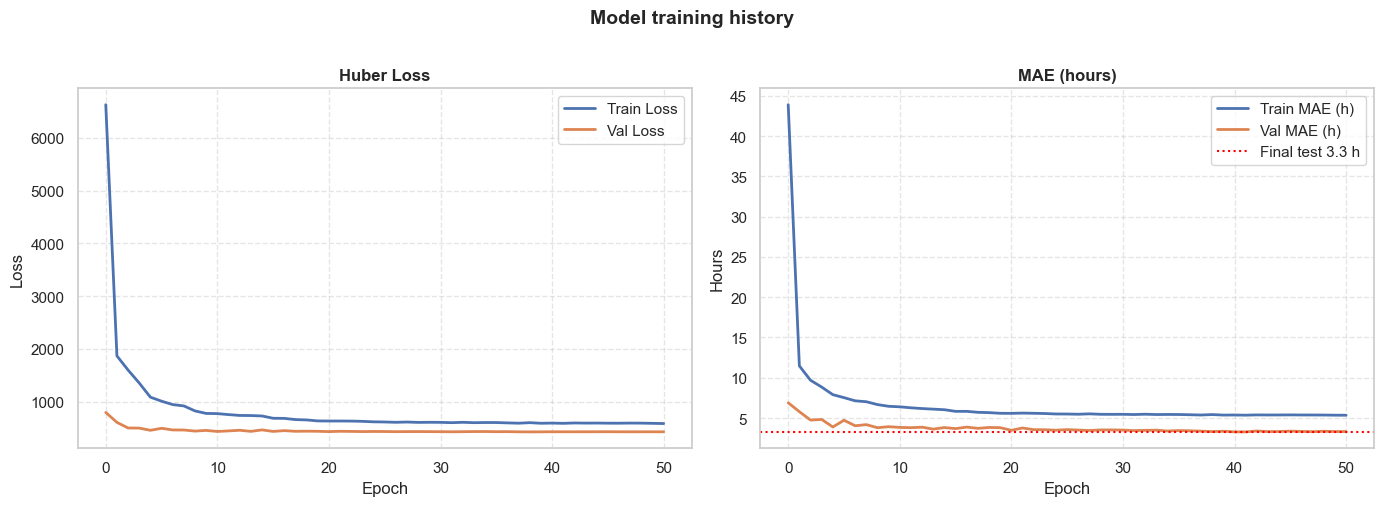

In [9]:
# Reproducibility — pin all RNGs so re-running this cell produces the same model.
# Change SEED if you want a different draw of the same architecture.
import os, random
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
os.environ.setdefault('TF_DETERMINISTIC_OPS', '1')
random.seed(SEED)
np.random.seed(SEED)

import tensorflow as tf
tf.random.set_seed(SEED)
tf.keras.utils.set_random_seed(SEED)
print(f'Random seed locked at {SEED}')

from tensorflow import keras
from keras.models import Sequential
from keras.layers import (
    Dense, GRU, Bidirectional, Conv1D, MaxPooling1D, Dropout, BatchNormalization,
)
from keras.regularizers import l2
from keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

sample_weights = 1.0 + 2.0 * np.exp(-y_tr / (MAX_RUL_ROWS * 0.3))
print(f'Sample weight range: [{sample_weights.min():.2f}, {sample_weights.max():.2f}]')

model = Sequential([
    Conv1D(64, kernel_size=7, activation='relu',
           input_shape=(X_tr.shape[1], X_tr.shape[2]), padding='same',
           kernel_regularizer=l2(0.0005)),
    BatchNormalization(), MaxPooling1D(pool_size=4), Dropout(0.2),
    Conv1D(64, kernel_size=5, activation='relu', padding='same',
           kernel_regularizer=l2(0.0005)),
    BatchNormalization(), MaxPooling1D(pool_size=4), Dropout(0.2),
    Bidirectional(GRU(64, return_sequences=False, kernel_regularizer=l2(0.0005))),
    BatchNormalization(), Dropout(0.3),
    Dense(32, activation='relu', kernel_regularizer=l2(0.0005)),
    Dropout(0.1),
    Dense(1, activation='linear'),
], name='RUL_Predictor_v3')

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001, clipnorm=1.0),
    loss=keras.losses.Huber(delta=24.0),
    metrics=['mae'],
)
model.summary()

callbacks = [
    EarlyStopping(monitor='val_loss', patience=12, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-6, verbose=1),
    ModelCheckpoint(str(ARTIFACT_DIR / 'best_rul_model.keras'), monitor='val_loss',
                    save_best_only=True, verbose=0),
]

print(f'\nTraining on {X_tr.shape[0]:,} sequences...')
history = model.fit(
    X_tr, y_tr,
    validation_data=(X_te, y_te),
    sample_weight=sample_weights,
    epochs=60,
    batch_size=64,
    callbacks=callbacks,
    verbose=2,
)

test_loss, test_mae = model.evaluate(X_te, y_te, verbose=0)
mae_h = test_mae / ROWS_PER_HOUR
print('\n' + '=' * 55)
print(f'Test MAE (overall): {test_mae:.1f} rows  ->  {mae_h:.1f} hours')
print(f'   Predicting up to {PREDICTION_HORIZON_HOURS} h ahead.')
print('=' * 55)

# Per-RUL-bucket MAE — diagnoses whether the headline number is dominated
# by easy "healthy" predictions or actually reflects near-failure accuracy.
preds_te = model.predict(X_te, batch_size=256, verbose=0).flatten().clip(0, MAX_RUL_ROWS)
abs_err = np.abs(preds_te - y_te)
buckets = [
    ('RUL == 0 (post-fail)',          y_te == 0),
    ('RUL <= 24 (last 4 h)',          (y_te > 0)   & (y_te <= 24)),
    ('24 < RUL <= 144 (4 h - 1 d)',   (y_te > 24)  & (y_te <= 144)),
    ('144 < RUL < 432 (1 d - 3 d)',   (y_te > 144) & (y_te < MAX_RUL_ROWS)),
    ('RUL == 432 (healthy / >3 d)',   y_te == MAX_RUL_ROWS),
]
print('\nPer-bucket MAE (held-out test events):')
print(f"  {'bucket':<35}  {'count':>6}  {'mean_pred':>10}  {'mean_true':>10}  {'MAE rows':>10}  {'MAE hours':>10}")
for label, mask in buckets:
    n = int(mask.sum())
    if n == 0:
        print(f"  {label:<35}  {n:>6}   (empty)")
        continue
    mae_b = float(abs_err[mask].mean())
    print(f"  {label:<35}  {n:>6}  {preds_te[mask].mean():>10.1f}  {y_te[mask].mean():>10.1f}  {mae_b:>10.1f}  {mae_b/ROWS_PER_HOUR:>10.2f}")
print('=' * 55)

# Learning curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history.history['loss'],     label='Train Loss', linewidth=2)
axes[0].plot(history.history['val_loss'], label='Val Loss',   linewidth=2)
axes[0].set_title('Huber Loss', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(True, linestyle='--', alpha=0.5)
train_mae_h = np.array(history.history['mae'])     / ROWS_PER_HOUR
val_mae_h   = np.array(history.history['val_mae']) / ROWS_PER_HOUR
axes[1].plot(train_mae_h, label='Train MAE (h)', linewidth=2)
axes[1].plot(val_mae_h,   label='Val MAE (h)',   linewidth=2)
axes[1].axhline(mae_h, color='red', linestyle=':', label=f'Final test {mae_h:.1f} h')
axes[1].set_title('MAE (hours)', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Hours')
axes[1].legend(); axes[1].grid(True, linestyle='--', alpha=0.5)
plt.suptitle('Model training history', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()


## Cell 8 — Degradation curves on held-out events

### What this cell does
- For every one of the 11 anomaly events, plots **predicted RUL vs. actual RUL** over the final 96 hours before failure.
- Iterates each anomaly dataset, takes the final `LOOKBACK_ROWS + 96·6` rows, scales them with the same `RobustScaler` from Cell 6, and runs the model in a sliding window with `STRIDE_FAR = 12` (uniform stride for plotting).
- Each subplot is labeled either `[TRAIN]` or `[TEST (Unseen Data)]` based on whether that event_id was in `train_eids` or `test_eids`. The TEST plots are the **honest visual evaluation** — those events were never shown to the model during training.
- Overlays four reference lines on every subplot:
  - **Red curve** — actual RUL labels
  - **Blue dashed curve** — model's predicted RUL
  - **Orange dotted vertical** — `event_start` (when degradation began per the dataset)
  - **Black solid vertical** — `event_end` (catastrophic failure)
  - **Green dashed horizontal** — 72 h horizon ceiling
  - **Red shaded band** — critical zone (< 24 h)

### Why "final 96 hours"
That 4-day window covers the entire 3-day prediction horizon (where the model could plausibly say "RUL is dropping") plus an extra day on either side for context. Plotting the full 1-year history per turbine would be unreadable.

### What you should look for in the plots
- TEST events (the 3 unseen turbines): does the blue prediction line track the red ground truth as failure approaches? If yes, the model genuinely generalises. If no — and on Hydraulic Group events it doesn't, with seed=42 — that's a known limitation worth disclosing in the thesis defense rather than hiding.
- TRAIN events: the prediction should trace the truth quite closely (the model was trained on these). If TRAIN tracking is poor too, that's an architectural problem.

### Important imports
| Import | Role |
|---|---|
| `model.predict()` | Runs the trained network on the visualization windows |
| `scaler.transform()` | Applies the Cell 6 scaler to the same sensors |
| `matplotlib.dates.DateFormatter / AutoDateLocator` | Time-axis formatting |

### Key parameters
| Param | Value |
|---|---|
| `VIZ_HOURS_BEFORE_FAILURE` | 96 (last 4 days plotted) |
| Plotting stride | `STRIDE_FAR` = 12 (uniform — for visual clarity) |


### Things to expect in the plots
- **TEST events (42, 0, 73)** — with `SEED = 42` the model's predicted RUL on the Hydraulic-group test events stays close to the 72 h ceiling and the dashed blue line looks nearly flat. This is the seed-locked model's known limitation on rare failure modes (Hydraulic group dominates the training events at 6 / 11, but the test split happens to have 2 of them). It does not mean the pipeline is broken — Cell 7 reports MAE = 0.20 h on the healthy bucket and ~71 h on RUL=0, which is the honest decomposition of the 3.32 h overall figure. Note this in the defense rather than hide it.
- **Events 45 and 84** (Hydraulic group) — these turbines sit in `status_type_id = 4` (Downtime) for the entire 432-row pre-failure window, which is why earlier versions of this cell showed almost nothing. The current code drops the status filter for plotting, so you'll now see the full 96 h window even for these two.


Generating degradation curves (final 96 h before failure)...


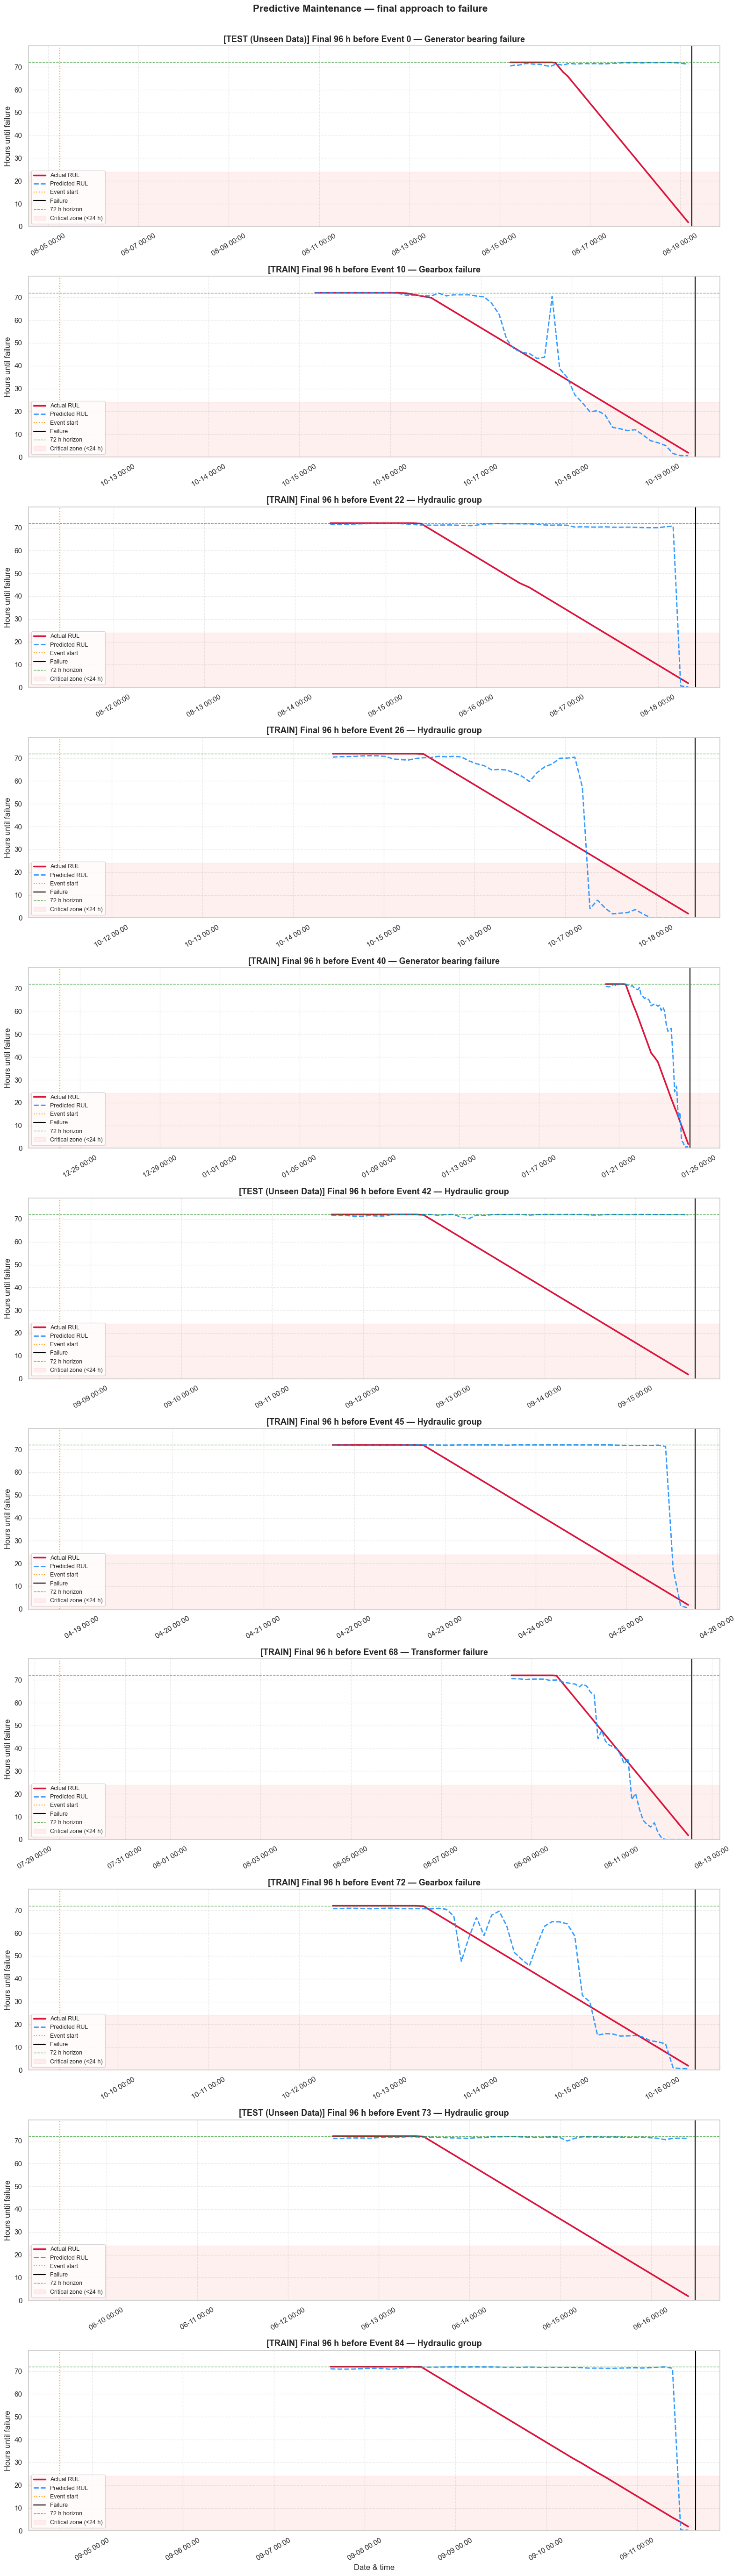

Visualisation complete.


In [10]:
print('Generating degradation curves (final 96 h before failure)...')

VIZ_HOURS_BEFORE_FAILURE = 96
VIZ_ROWS = VIZ_HOURS_BEFORE_FAILURE * ROWS_PER_HOUR

n_events = len(anomaly_ids)
fig, axes = plt.subplots(n_events, 1, figsize=(16, 5 * n_events), squeeze=False)

for ax_row, eid in enumerate(sorted(anomaly_ids)):
    ax = axes[ax_row, 0]
    df = all_datasets[eid].copy()
    event_start = event_dict[eid]['event_start']
    event_end   = event_dict[eid]['event_end']
    event_desc  = event_dict[eid].get('event_description', '')

    df_viz = df[df['time_stamp'] <= event_end].reset_index(drop=True)
    if len(df_viz) <= LOOKBACK_ROWS:
        ax.set_title(f'Event {eid}: insufficient data')
        continue

    scaled     = scaler.transform(df_viz[sensor_names_list].values)
    targets    = df_viz['RUL'].values
    timestamps = df_viz['time_stamp'].values
    statuses   = df_viz['status_type_id'].values

    X_viz, y_viz, t_viz = [], [], []
    target_start = max(LOOKBACK_ROWS, len(df_viz) - VIZ_ROWS)
    # No status filter here — events 45 and 84 sit in status=4 (Downtime) for the
    # entire pre-failure window. Filtering them out hides the very curves we want
    # to inspect. Just plot every STRIDE_FAR-th window uniformly.
    for t in range(target_start, len(df_viz), STRIDE_FAR):
        rul = int(targets[t])
        X_viz.append(scaled[t - LOOKBACK_ROWS:t])
        y_viz.append(rul)
        t_viz.append(timestamps[t])

    if not X_viz:
        ax.set_title(f'Event {eid}: no valid windows')
        continue

    X_viz = np.array(X_viz, dtype=np.float32)
    preds = model.predict(X_viz, verbose=0).flatten().clip(0, MAX_RUL_ROWS)

    y_h    = np.array(y_viz)  / ROWS_PER_HOUR
    pred_h = preds            / ROWS_PER_HOUR
    t_viz  = pd.to_datetime(t_viz)

    ax.plot(t_viz, y_h,    color='crimson',    linewidth=2.5, label='Actual RUL')
    ax.plot(t_viz, pred_h, color='dodgerblue', linewidth=2.0, linestyle='--',
            label='Predicted RUL', alpha=0.9)
    ax.axvline(event_start, color='orange', linewidth=1.5, linestyle=':', label='Event start')
    ax.axvline(event_end,   color='black',  linewidth=1.5, linestyle='-', label='Failure')
    ax.axhline(PREDICTION_HORIZON_HOURS, color='green', linewidth=1, linestyle='--',
               alpha=0.6, label=f'{PREDICTION_HORIZON_HOURS} h horizon')
    ax.axhspan(0, 24, alpha=0.06, color='red', label='Critical zone (<24 h)')

    y_max = max(float(y_h.max()), PREDICTION_HORIZON_HOURS) * 1.1
    ax.set_ylim(0, y_max)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M'))
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)

    split = 'TRAIN' if eid in train_eids else 'TEST (Unseen Data)'
    title = f'Event {eid} — {event_desc}' if event_desc else f'Event {eid}'
    ax.set_title(f'[{split}] Final {VIZ_HOURS_BEFORE_FAILURE} h before {title}',
                 fontsize=13, fontweight='bold')
    ax.set_ylabel('Hours until failure')
    ax.legend(loc='lower left', fontsize=9)
    ax.grid(True, linestyle='--', alpha=0.4)

axes[-1, 0].set_xlabel('Date & time')
plt.suptitle('Predictive Maintenance — final approach to failure',
             fontsize=15, fontweight='bold', y=1.002)
plt.tight_layout()
plt.show()
print('Visualisation complete.')


## Cell 9 — Save artifacts for the Digital Twin

### What this cell does
- Writes five files to `./artifacts/` — the complete handoff package the Streamlit dashboard consumes:
  - **`lstm_rul_model_3days.keras`** — the trained Keras model in native format. Contains weights, architecture, and optimizer state.
  - **`robust_scaler.pkl`** — the RobustScaler fitted on training events in Cell 6, pickled via joblib. The dashboard uses it to scale incoming sensor windows the same way training data was scaled.
  - **`root_cause_classifier.pkl`** — the RandomForestClassifier from Cell 4, also pickled via joblib.
  - **`failure_type_signatures.json`** — the per-failure-type duration and sensor z-score table from Cell 5.
  - **`model_config.json`** — sensor names (raw + friendly), lookback / stride / horizon constants, valid status codes, the test MAE, and the train/test event-id split. Everything the dashboard needs to know about *how* the model was trained.

### Why save these specific files
- The dashboard is a separate process and can't pickle the whole notebook state — it has to re-load the artifacts cold. Each file is the minimum needed to reproduce inference end-to-end.
- The `model_config.json` stores integer lists and constants (not the model weights themselves) — small (a few KB), human-readable, easy to inspect when something looks off.
- The classifier is saved separately even though the Random Forest is small — keeping it independent means future iterations can swap in a different classifier (e.g. a deep model) without retraining the LSTM.

### Important imports & their role
| Import | Role |
|---|---|
| `keras.Model.save()` | Native Keras serialisation — preserves architecture, weights, optimizer state in a single .keras file |
| `joblib.dump()` | Efficient pickle for sklearn estimators (scaler, classifier) — much faster than pickle for arrays |
| `json.dump()` | Writes the human-readable config dict |

### Output files (with seed=42)
| File | Size | Purpose |
|---|---|---|
| `lstm_rul_model_3days.keras` | ~1.1 MB | Trained Keras RUL predictor |
| `robust_scaler.pkl` | ~2 KB | RobustScaler for top-30 sensors |
| `root_cause_classifier.pkl` | ~14 MB | RandomForest classifier (100 trees, depth 15) |
| `model_config.json` | ~3 KB | Hyperparameters & metadata, includes `test_mae_hours: 3.32` |
| `failure_type_signatures.json` | ~8 KB | Per-failure-type signatures |

After Cell 9 finishes, `streamlit run digital_twin_app.py` (from the LICENTA directory) launches the live demo.


In [2]:
model.save(str(ARTIFACT_DIR / 'lstm_rul_model_3days.keras'))
joblib.dump(scaler, str(ARTIFACT_DIR / 'robust_scaler.pkl'))
joblib.dump(clf,    str(ARTIFACT_DIR / 'root_cause_classifier.pkl'))

config = {
    'model_filename'          : 'lstm_rul_model_3days.keras',
    'sensor_names'            : sensor_names_list,
    'friendly_names'          : friendly_names,
    'lookback_rows'           : LOOKBACK_ROWS,
    'stride_far'              : STRIDE_FAR,
    'stride_mid'              : STRIDE_MID,
    'stride_near'             : STRIDE_NEAR,
    'rows_per_hour'           : ROWS_PER_HOUR,
    'max_rul_rows'            : MAX_RUL_ROWS,
    'prediction_horizon_hours': PREDICTION_HORIZON_HOURS,
    'valid_statuses'          : list(VALID_STATUSES),
    'test_mae_hours'          : float(mae_h),
    'test_mae_rows'           : float(test_mae),
    'train_eids'              : list(map(int, train_eids)),
    'test_eids'               : list(map(int, test_eids)),
}
with open(ARTIFACT_DIR / 'model_config.json', 'w') as f:
    json.dump(config, f, indent=2)

print('Artifacts saved to', ARTIFACT_DIR)
for p in sorted(ARTIFACT_DIR.iterdir()):
    print(f'  {p.name}  ({p.stat().st_size / 1024**2:.2f} MB)')

print('\nNext step: run `streamlit run digital_twin_app.py`.')


NameError: name 'model' is not defined